# Hourly Temperature Comparison (Temperature on Y-Axis)

This notebook replicates the format and color scheme from `Compare_Graphs.ipynb`, but plots raw Temperature (°C) on the y-axis instead of temperature differences. We generate four boxplot-based charts for UNshaded structures only and constrain BOTH groups to the POST‑INTERVENTION window for fair comparison:

- Rainbow Field: CONTROL vs MEB
- Rainbow Field: CONTROL vs RBF
- Sports Complex: CONTROL vs MEB
- Sports Complex: CONTROL vs RBF

It uses `master_dataframe.csv` for per-logger temperatures and `logger_flags.csv` for metadata and intervention dates. Basic validity filtering is applied consistently to remove zeros and implausible values (e.g., < 20°C or > 60°C).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

# Color scheme aligned with Compare_Graphs
DEFAULT_COLORS = {
    'control_range': '#E0E0E0',
    'intervention_range': '#ADD8E6',
    'control_mean': '#FF6961',
    'intervention_mean': '#6495ED',
    'control_box': '#D3D3D3',
    'intervention_box': '#87CEFA'
}

TEMP_MAX = 60
TEMP_MIN_PLAUSIBLE = -10

logger_flags_df = pd.read_csv('logger_flags.csv')
# Normalize Shaded to boolean
logger_flags_df['Shaded'] = logger_flags_df['Shaded'].apply(lambda v: str(v).lower() in ['true', '1', 'yes'])

master_df = pd.read_csv('master_dataframe.csv', parse_dates=['DateTime'])

# Ensure DateTime sorted
master_df = master_df.sort_values('DateTime').reset_index(drop=True)



In [2]:
def create_average_day_temperature_plot(
    settlement,
    intervention_type='MEB',
    period='Full',
    shaded=False,
    colors=None
):
    """
    Create comparison plot of raw Temperature for an average 24-hour day.

    Parameters
    ----------
    settlement : str
        Name of the settlement
    intervention_type : str
        Type of intervention ('MEB' or 'RBF')
    period : str
        'Full', 'Day', or 'Night'
    shaded : bool
        Whether to analyze shaded (True) or unshaded (False) structures
    colors : dict, optional
        Dictionary to customize plot colors
    """
    default_colors = DEFAULT_COLORS.copy()
    if colors:
        default_colors.update(colors)

    # Filter loggers (explicitly unshaded when shaded=False)
    control_loggers = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == 'CONTROL') &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()

    intervention_loggers = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == intervention_type) &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()

    if len(intervention_loggers) == 0 or len(control_loggers) == 0:
        print(f"No matching loggers for {settlement} - {intervention_type} - {'Shaded' if shaded else 'Unshaded'}")
        return

    # Dates
    intervention_start = pd.to_datetime(
        logger_flags_df[
            (logger_flags_df['Settlement'] == settlement) &
            (logger_flags_df['Intervention'] == intervention_type)
        ]['Intervention_Start'].iloc[0]
    )
    intervention_end = pd.to_datetime(
        logger_flags_df[
            (logger_flags_df['Settlement'] == settlement) &
            (logger_flags_df['Intervention'] == intervention_type)
        ]['Post_Intervention_End'].iloc[0]
    )

    # Split by period and apply validity filtering
    df = master_df.copy()
    df['Hour'] = df['DateTime'].dt.hour

    # Keep only plausible temperatures (relaxed lower bound to retain nights)
    for col in [c for c in df.columns if c != 'DateTime' and c != 'Env_Temperature']:
        if col in df.columns:
            df[col] = df[col].where((df[col] >= TEMP_MIN_PLAUSIBLE) & (df[col] <= TEMP_MAX))

    if period == 'Day':
        df = df[(df['Hour'] >= 6) & (df['Hour'] < 19)]
        hours_range = list(range(6, 19))
    elif period == 'Night':
        df = df[(df['Hour'] < 6) | (df['Hour'] >= 19)]
        hours_range = list(range(19, 24)) + list(range(0, 6))
    else:
        hours_range = list(range(24))

    # Windows: both groups constrained to post-intervention
    post_df = df[(df['DateTime'] >= intervention_start) & (df['DateTime'] <= intervention_end)].copy()

    # Active logger detection within post window
    def filter_active_loggers(loggers, window):
        return [lg for lg in loggers if lg in window.columns and not window[lg].dropna().empty]

    active_control = filter_active_loggers(control_loggers, post_df)
    active_intervention = filter_active_loggers(intervention_loggers, post_df)

    if len(active_control) == 0 or len(active_intervention) == 0:
        print(f"Insufficient active loggers for {settlement} - {intervention_type} - {'Shaded' if shaded else 'Unshaded'} in post window")
        return

    # Build frames used for stats
    control_post = post_df[active_control]
    intervention_post = post_df[active_intervention]

    def calculate_hourly_stats(loggers, data, hours):
        stats_rows = []
        # Use hour mapping aligned to the provided data subset
        hour_for_data = post_df['Hour'].loc[data.index]
        for hr in hours:
            mask = hour_for_data == hr
            if not mask.any():
                continue
            hour_block = data.loc[mask, loggers]
            if hour_block.empty:
                continue
            hour_block = hour_block.replace(0, np.nan).dropna(how='all')
            if hour_block.empty:
                continue
            if len(loggers) == 1:
                series = hour_block.iloc[:, 0]
                mean_val = series.mean()
                std_val = series.std()
                range_margin = std_val if pd.notna(std_val) and std_val >= 0.1 else max(0.1, abs(mean_val) * 0.1)
                max_val = mean_val + range_margin
                min_val = mean_val - range_margin
                values_for_box = series.values
            else:
                row_means = hour_block.mean(axis=1)
                mean_val = row_means.mean()
                std_val = row_means.std()
                max_val = hour_block.max(axis=1).mean()
                min_val = hour_block.min(axis=1).mean()
                values_for_box = row_means.values
            stats_rows.append({
                'Hour': hr,
                'max': max_val,
                'min': min_val,
                'mean': mean_val,
                'std': 0 if pd.isna(std_val) else std_val,
                'values': values_for_box
            })
        return pd.DataFrame(stats_rows)

    control_stats = calculate_hourly_stats(active_control, control_post, hours_range)
    intervention_stats = calculate_hourly_stats(active_intervention, intervention_post, hours_range)

    if control_stats.empty or intervention_stats.empty:
        print("No data to plot")
        return

    # Plot
    fig, ax = plt.subplots(figsize=(15, 7))

    # Ranges
    ax.fill_between(control_stats['Hour'], control_stats['max'], control_stats['min'],
                    alpha=0.3, color=default_colors['control_range'], label='Control Range')
    ax.fill_between(intervention_stats['Hour'], intervention_stats['max'], intervention_stats['min'],
                    alpha=0.5, color=default_colors['intervention_range'], label='Intervention Range')

    # Means
    control_mean_line, = ax.plot(control_stats['Hour'], control_stats['mean'],
                                 color=default_colors['control_mean'], linewidth=2, label='Control Mean')
    intervention_mean_line, = ax.plot(intervention_stats['Hour'], intervention_stats['mean'],
                                      color=default_colors['intervention_mean'], linewidth=2, label='Intervention Mean')

    # Boxplots per hour
    control_boxes = []
    intervention_boxes = []
    for _, row in control_stats.iterrows():
        control_boxes.append(
            ax.boxplot(row['values'], positions=[row['Hour']], widths=0.5, patch_artist=True,
                       boxprops=dict(facecolor=default_colors['control_box'], color='gray'),
                       medianprops=dict(color=default_colors['control_mean']), showfliers=False)
        )
    for _, row in intervention_stats.iterrows():
        intervention_boxes.append(
            ax.boxplot(row['values'], positions=[row['Hour']], widths=0.5, patch_artist=True,
                       boxprops=dict(facecolor=default_colors['intervention_box'], color='blue'),
                       medianprops=dict(color=default_colors['intervention_mean']), showfliers=False)
        )

    # Legend
    legend_elements = [
        (Patch(facecolor=default_colors['control_range'], alpha=0.3), [], 'Control Range'),
        (Patch(facecolor=default_colors['intervention_range'], alpha=0.5), [], 'Intervention Range'),
        (Patch(facecolor=default_colors['control_mean']), [control_mean_line], 'Control Mean'),
        (Patch(facecolor=default_colors['intervention_mean']), [intervention_mean_line], 'Intervention Mean'),
        (Patch(facecolor=default_colors['control_box'], alpha=1.0), control_boxes, 'Control Hourly Distribution'),
        (Patch(facecolor=default_colors['intervention_box'], alpha=1.0), intervention_boxes, 'Intervention Hourly Distribution')
    ]

    # Axes
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Temperature (°C)')
    shading_str = 'Shaded' if shaded else 'Unshaded'
    period_str = f' ({period}time)' if period != 'Full' else ''
    ax.set_title(f'Average Daily Temperature{period_str}: {shading_str} Control vs {intervention_type} in {settlement}')

    if period == 'Night':
        plot_hours = list(range(19, 24)) + list(range(24, 30))
        ax.set_xticks(plot_hours)
        ax.set_xlim(18.5, 29.5)
        ax.set_xticklabels([f"{h:02d}:00" if h < 24 else f"{h-24:02d}:00" for h in plot_hours])
    elif period == 'Day':
        ax.set_xticks(hours_range)
        ax.set_xlim(5.5, 19.5)
        ax.set_xticklabels([f"{h:02d}:00" for h in hours_range])
    else:
        ax.set_xticks(hours_range)
        ax.set_xlim(-0.5, 23.5)
        ax.set_xticklabels([f"{h:02d}:00" for h in hours_range])

    plt.tight_layout()
    plt.show()


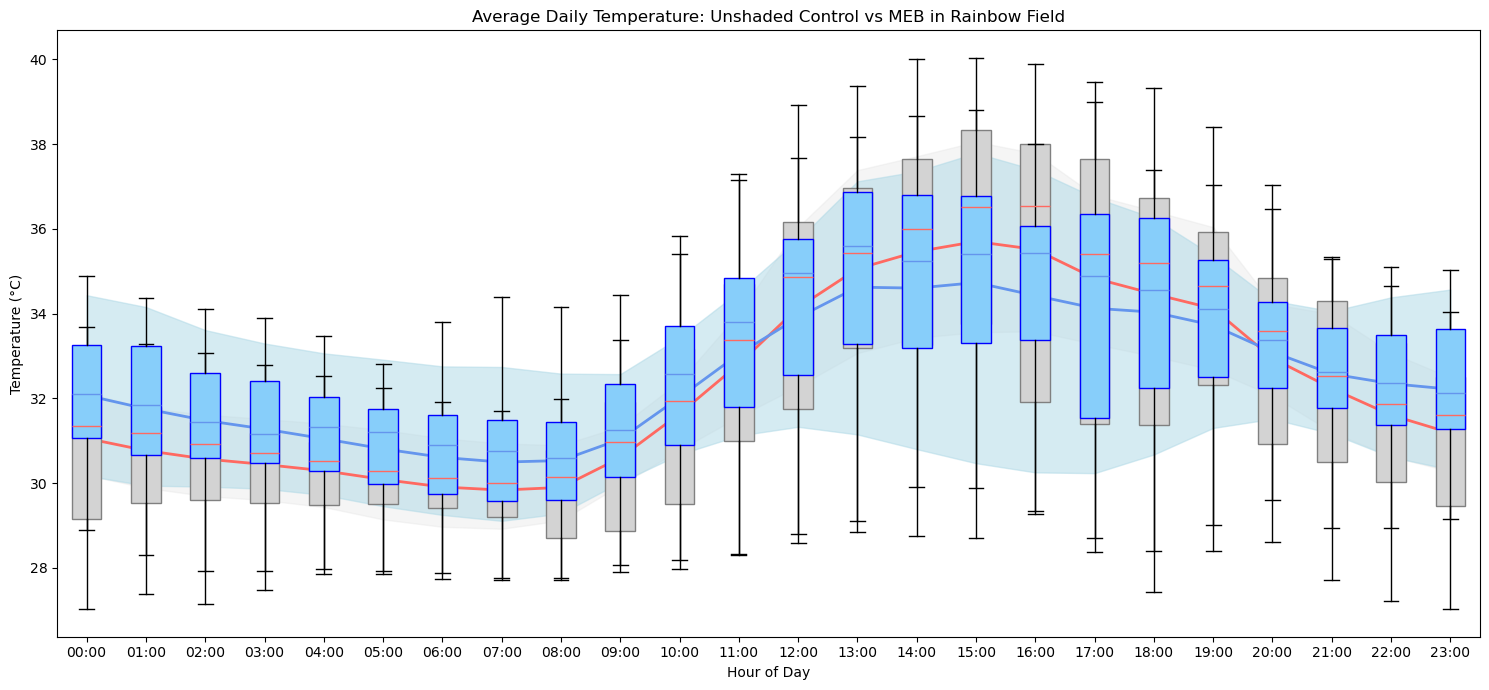

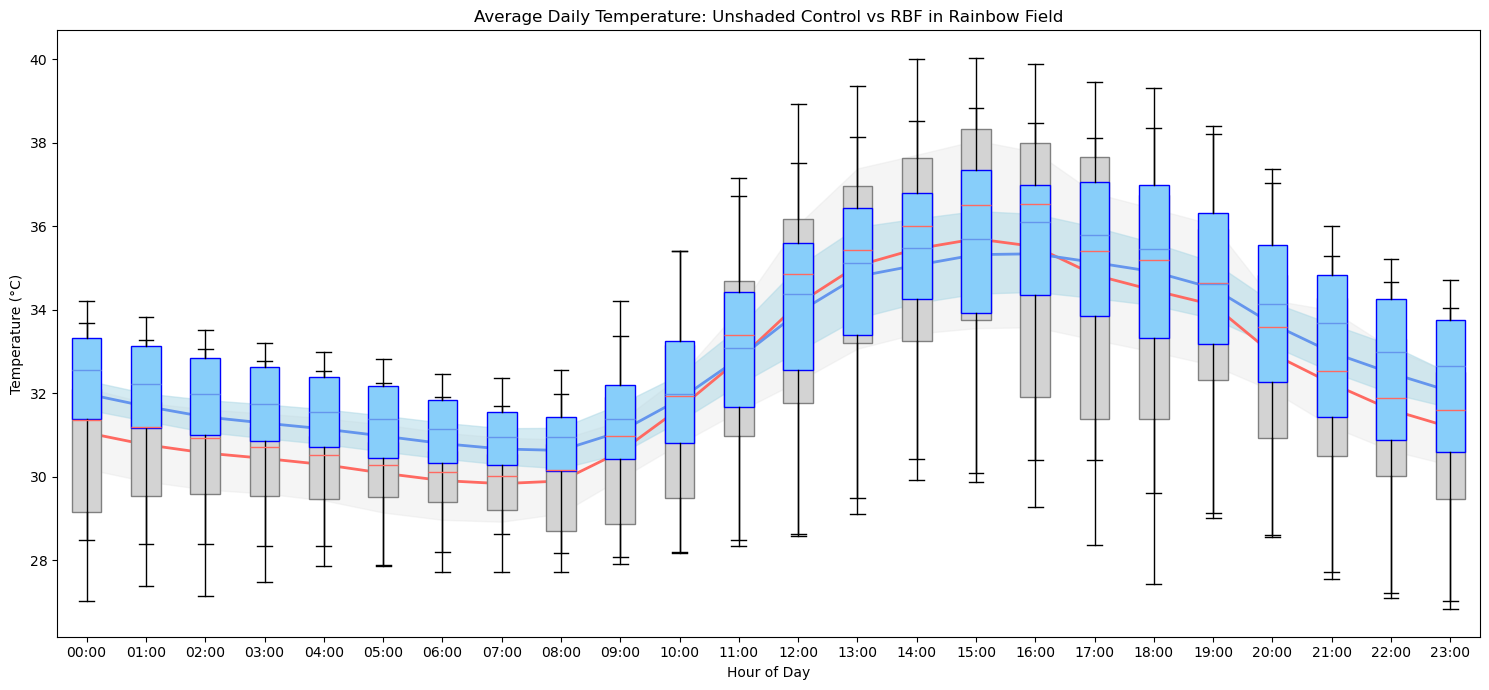

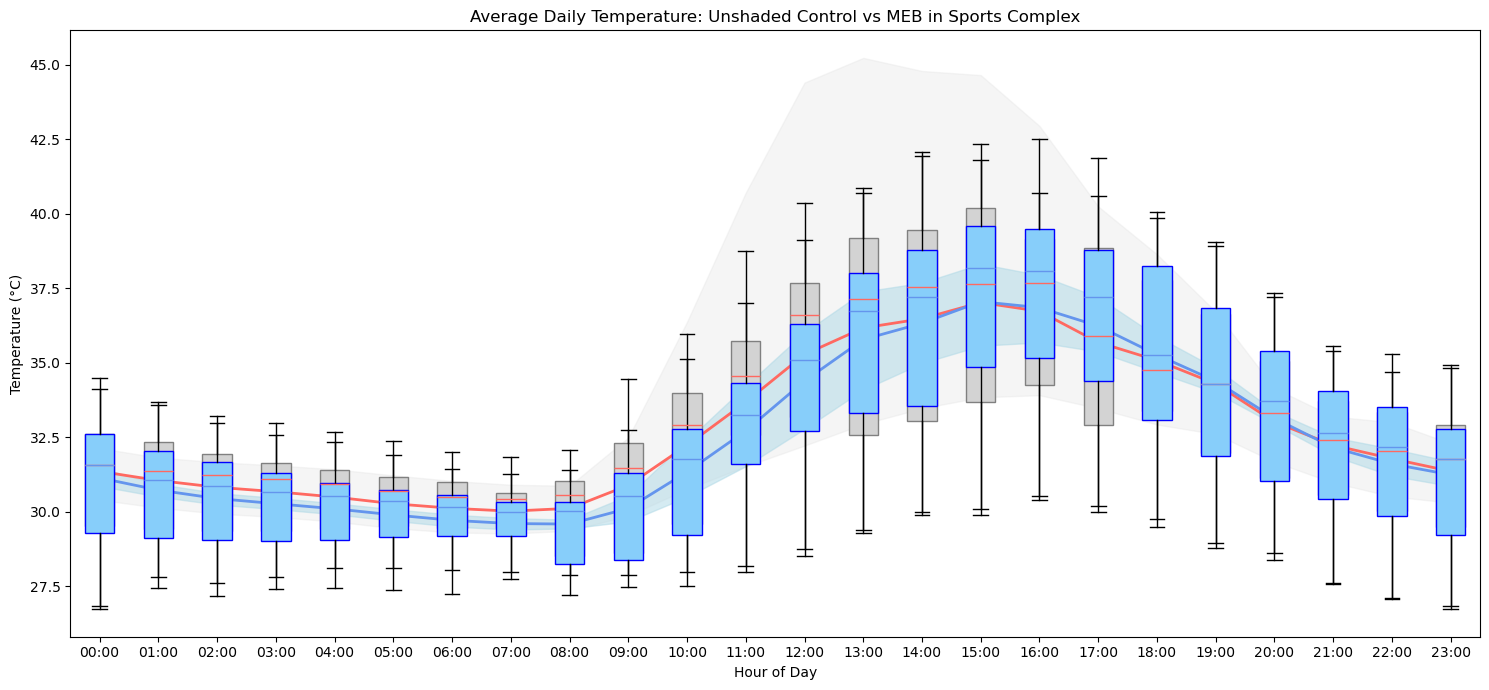

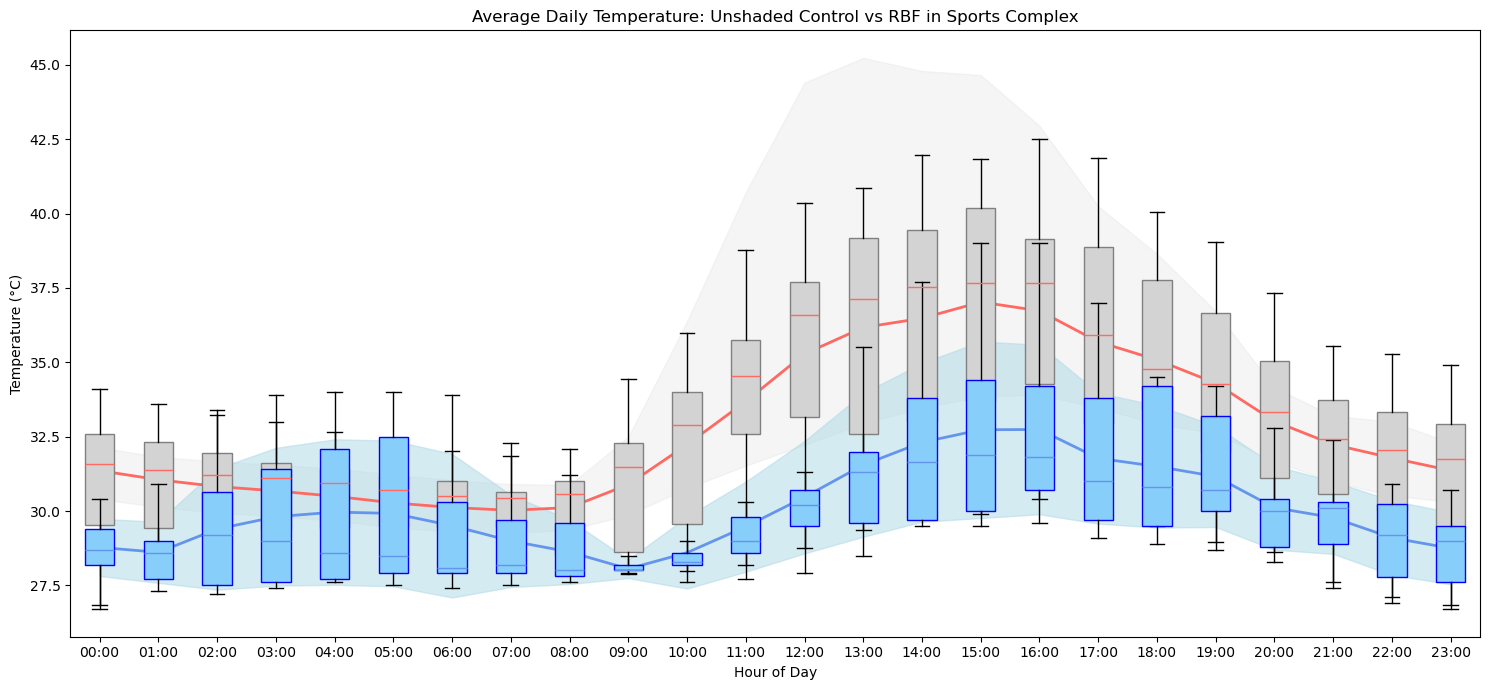

In [3]:
# Generate the four requested plots (Unshaded only)
settlements = ['Rainbow Field', 'Sports Complex']
interventions = ['MEB', 'RBF']

for st in settlements:
    for itv in interventions:
        try:
            create_average_day_temperature_plot(
                settlement=st,
                intervention_type=itv,
                period='Full',
                shaded=False,
                colors=DEFAULT_COLORS
            )
        except Exception as e:
            print(f"Error for {st} - {itv}: {e}")


In [4]:
# Compute peak temperature reduction (unshaded, post-intervention)
# Validates the abstract's "peaks at ~4°C" statement

settlements = ['Rainbow Field', 'Sports Complex']
interventions = ['MEB', 'RBF']

def get_intervention_window(settlement, intervention):
    row = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == intervention)
    ].iloc[0]
    return pd.to_datetime(row['Intervention_Start']), pd.to_datetime(row['Post_Intervention_End'])

def select_unshaded_loggers(settlement, intervention_value):
    return logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == intervention_value) &
        (logger_flags_df['Shaded'] == False)
    ]['Loggers'].tolist()

# Prepare base dataframe with plausibility filter and hour
df_base = master_df.copy()
df_base['Hour'] = df_base['DateTime'].dt.hour
for col in [c for c in df_base.columns if c not in ['DateTime', 'Env_Temperature', 'Hour']]:
    df_base[col] = df_base[col].where((df_base[col] >= TEMP_MIN_PLAUSIBLE) & (df_base[col] <= TEMP_MAX))

reductions = []

for st in settlements:
    for itv in interventions:
        # Get post window for this settlement-intervention
        try:
            start, end = get_intervention_window(st, itv)
        except IndexError:
            continue
        window_df = df_base[(df_base['DateTime'] >= start) & (df_base['DateTime'] <= end)].copy()
        if window_df.empty:
            continue

        ctrl_loggers = select_unshaded_loggers(st, 'CONTROL')
        itv_loggers = select_unshaded_loggers(st, itv)

        # Determine active loggers in this window
        ctrl_active = [lg for lg in ctrl_loggers if lg in window_df.columns and window_df[lg].notna().any()]
        itv_active = [lg for lg in itv_loggers if lg in window_df.columns and window_df[lg].notna().any()]
        if not ctrl_active or not itv_active:
            continue

        ctrl_mean = window_df[ctrl_active].mean(axis=1)
        itv_mean = window_df[itv_active].mean(axis=1)
        red = (ctrl_mean - itv_mean).to_frame('Reduction')
        red['DateTime'] = window_df['DateTime'].values
        red['Hour'] = window_df['Hour'].values
        red['Settlement'] = st
        red['Intervention'] = itv
        reductions.append(red)

peak_df = pd.concat(reductions, ignore_index=True) if reductions else pd.DataFrame(columns=['Reduction','DateTime','Hour','Settlement','Intervention'])

if not peak_df.empty:
    overall_peak_instant = np.nanmax(peak_df['Reduction'].values)
    hourly_mean = peak_df.groupby('Hour')['Reduction'].mean()
    peak_hourly_mean = hourly_mean.max()
    by_intervention_peak = peak_df.groupby('Intervention')['Reduction'].max().round(2).to_dict()

    print(f"Peak instantaneous reduction (°C): {overall_peak_instant:.2f}")
    print(f"Peak hourly mean reduction (°C): {peak_hourly_mean:.2f}")
    print(f"Peak instantaneous by intervention (°C): {by_intervention_peak}")
else:
    print("No data available to compute peak reduction.")


Peak instantaneous reduction (°C): 4.88
Peak hourly mean reduction (°C): 0.95
Peak instantaneous by intervention (°C): {'MEB': 4.88, 'RBF': 4.43}


In [5]:
# Validate total number of minute-level temperature records (~2.28M)

from pathlib import Path

def format_millions(value):
    return f"{value:,.0f} (~{value/1_000_000:.2f}M)"

# Count total non-null logger readings in master_dataframe
logger_cols = [c for c in master_df.columns if c not in ['DateTime', 'Env_Temperature']]
master_total_points = master_df[logger_cols].notna().sum().sum()
print(f"Total non-null temperature points in master_dataframe.csv: {format_millions(master_total_points)}")

# If available, also report total observations used in DID dataset
did_path = Path('did_df.csv')
if did_path.exists():
    try:
        # Read minimally to count rows efficiently
        did_total_rows = sum(1 for _ in open(did_path, 'r', encoding='utf-8', errors='ignore')) - 1  # minus header
        print(f"Total observations in did_df.csv: {format_millions(did_total_rows)}")
    except Exception as e:
        print(f"Could not count rows in did_df.csv due to: {e}")

# Quick check against 2.28M claim
claimed = 2_280_000
diff_master = master_total_points - claimed
print(f"Difference vs 2.28M (master): {diff_master:+,}")

if did_path.exists():
    try:
        diff_did = did_total_rows - claimed
        print(f"Difference vs 2.28M (did_df): {diff_did:+,}")
    except NameError:
        pass


Total non-null temperature points in master_dataframe.csv: 2,389,557 (~2.39M)
Total observations in did_df.csv: 2,279,880 (~2.28M)
Difference vs 2.28M (master): +109,557
Difference vs 2.28M (did_df): -120


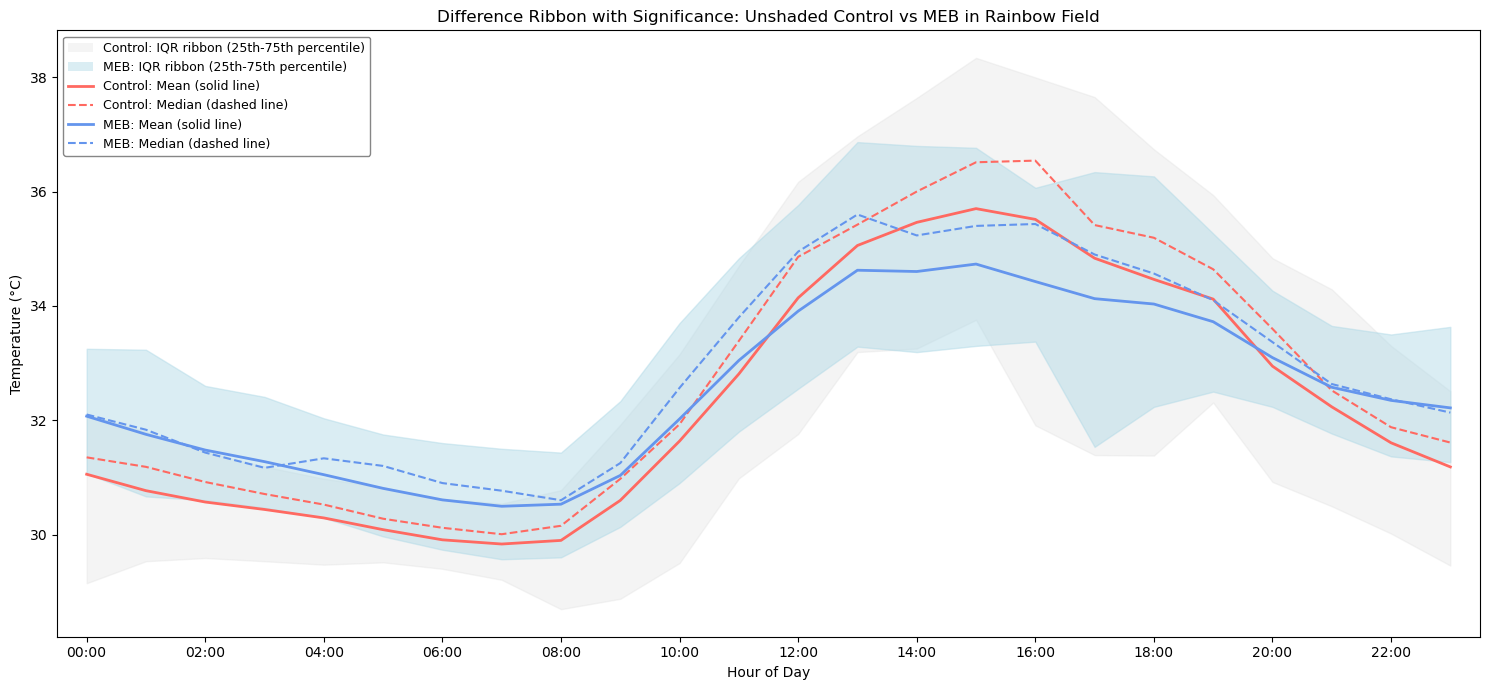

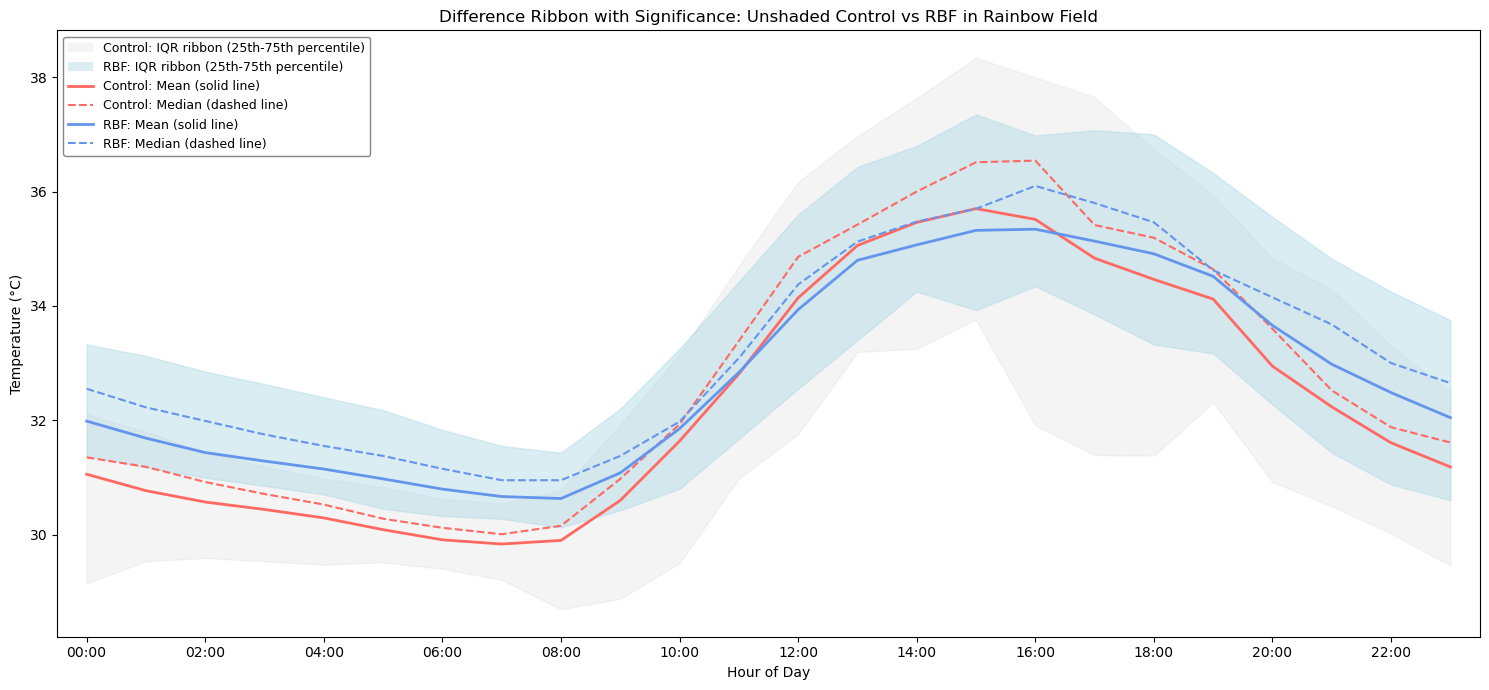

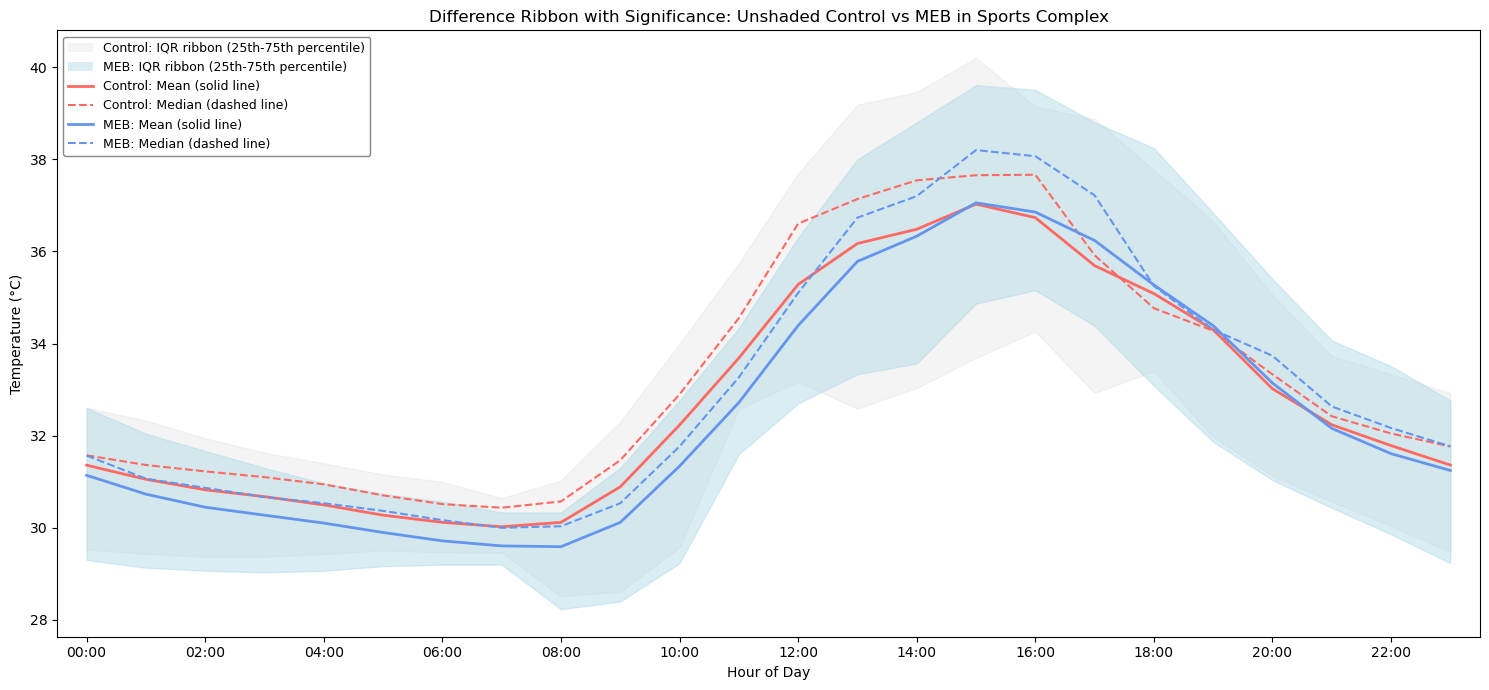

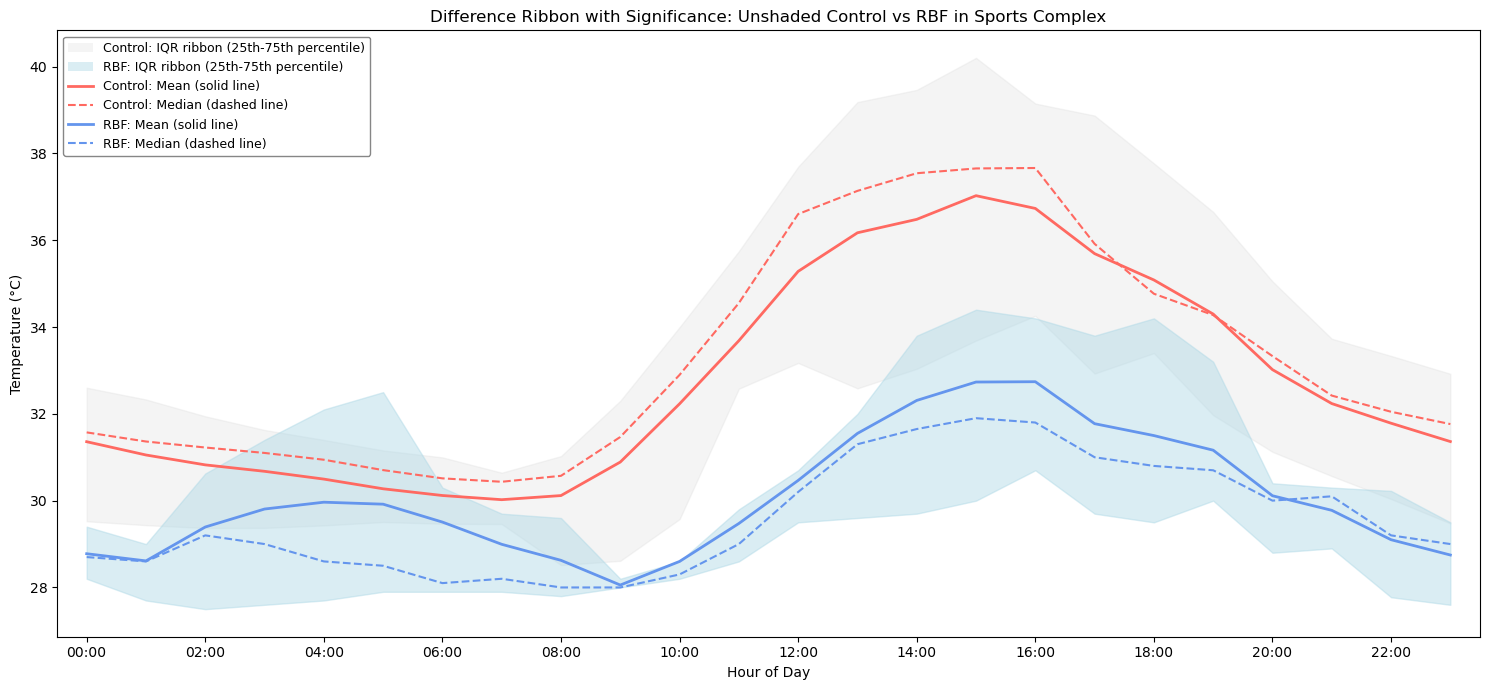

In [10]:
# Difference ribbon (IQR) with mean and median lines (unshaded, post-intervention)
# - Mean and median Temperature lines for Control and Intervention
# - IQR (25–75%) ribbons for each group

from matplotlib.patches import Patch

def create_difference_ribbon_plot(
    settlement,
    intervention_type='MEB',
    period='Full',
    shaded=False,
    colors=None
):
    default_colors = DEFAULT_COLORS.copy()
    if colors:
        default_colors.update(colors)

    # Get intervention window
    rows = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == intervention_type)
    ]
    if rows.empty:
        print(f"No intervention rows for {settlement} - {intervention_type}")
        return
    start = pd.to_datetime(rows['Intervention_Start'].iloc[0])
    end = pd.to_datetime(rows['Post_Intervention_End'].iloc[0])

    # Select unshaded loggers
    control_loggers = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == 'CONTROL') &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()
    intervention_loggers = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == intervention_type) &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()

    if not control_loggers or not intervention_loggers:
        print(f"No matching unshaded loggers for {settlement} - {intervention_type}")
        return

    # Build post window with plausibility filter
    df = master_df.copy()
    df['Hour'] = df['DateTime'].dt.hour
    for col in [c for c in df.columns if c not in ['DateTime', 'Env_Temperature', 'Hour']]:
        df[col] = df[col].where((df[col] >= TEMP_MIN_PLAUSIBLE) & (df[col] <= TEMP_MAX))

    if period == 'Day':
        df = df[(df['Hour'] >= 6) & (df['Hour'] < 19)]
        hours_range = list(range(6, 19))
    elif period == 'Night':
        df = df[(df['Hour'] < 6) | (df['Hour'] >= 19)]
        hours_range = list(range(19, 24)) + list(range(0, 6))
    else:
        hours_range = list(range(24))

    post_df = df[(df['DateTime'] >= start) & (df['DateTime'] <= end)].copy()
    if post_df.empty:
        print(f"No post-intervention data for {settlement} - {intervention_type}")
        return

    # Active loggers within window
    ctrl_active = [lg for lg in control_loggers if lg in post_df.columns and post_df[lg].notna().any()]
    itv_active = [lg for lg in intervention_loggers if lg in post_df.columns and post_df[lg].notna().any()]
    if not ctrl_active or not itv_active:
        print(f"Insufficient active loggers for {settlement} - {intervention_type}")
        return

    hours, c_mean, c_med, c_q25, c_q75 = [], [], [], [], []
    i_mean, i_med, i_q25, i_q75 = [], [], [], []

    hour_series = post_df['Hour']

    for hr in hours_range:
        idx = (hour_series == hr)
        if not idx.any():
            continue
        block = post_df.loc[idx]
        # Per-timestamp means across loggers
        ctrl_rows = block[ctrl_active].mean(axis=1, skipna=True)
        itv_rows = block[itv_active].mean(axis=1, skipna=True)

        ctrl_rows = ctrl_rows.dropna()
        itv_rows = itv_rows.dropna()
        if ctrl_rows.empty or itv_rows.empty:
            continue

        # For descriptives (IQR), use each group's distribution
        hours.append(hr)
        c_mean.append(ctrl_rows.mean())
        c_med.append(ctrl_rows.median())
        c_q25.append(ctrl_rows.quantile(0.25))
        c_q75.append(ctrl_rows.quantile(0.75))
        i_mean.append(itv_rows.mean())
        i_med.append(itv_rows.median())
        i_q25.append(itv_rows.quantile(0.25))
        i_q75.append(itv_rows.quantile(0.75))

    if not hours:
        print(f"No hourly data available for {settlement} - {intervention_type}")
        return

    hours = np.array(hours)
    c_mean = np.array(c_mean); c_med = np.array(c_med); c_q25 = np.array(c_q25); c_q75 = np.array(c_q75)
    i_mean = np.array(i_mean); i_med = np.array(i_med); i_q25 = np.array(i_q25); i_q75 = np.array(i_q75)

    fig, ax = plt.subplots(figsize=(15, 7))

    # IQR ribbons
    ax.fill_between(hours, c_q75, c_q25, color=default_colors['control_range'], alpha=0.35, label='Control IQR')
    ax.fill_between(hours, i_q75, i_q25, color=default_colors['intervention_range'], alpha=0.45, label='Intervention IQR')

    # Mean and median lines
    ctrl_mean_line, = ax.plot(hours, c_mean, color=default_colors['control_mean'], linewidth=2, label='Control Mean')
    ctrl_med_line, = ax.plot(hours, c_med, color=default_colors['control_mean'], linewidth=1.5, linestyle='--', label='Control Median')
    itv_mean_line, = ax.plot(hours, i_mean, color=default_colors['intervention_mean'], linewidth=2, label=f'{intervention_type} Mean')
    itv_med_line, = ax.plot(hours, i_med, color=default_colors['intervention_mean'], linewidth=1.5, linestyle='--', label=f'{intervention_type} Median')

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Temperature (°C)')
    shading_str = 'Shaded' if shaded else 'Unshaded'
    period_str = f' ({period}time)' if period != 'Full' else ''
    ax.set_title(f'Difference Ribbon with Significance{period_str}: {shading_str} Control vs {intervention_type} in {settlement}')

    # X ticks
    if period == 'Night':
        plot_hours = list(range(19, 24)) + list(range(24, 30))
        ax.set_xticks(plot_hours)
        ax.set_xlim(18.5, 29.5)
        ax.set_xticklabels([f"{h:02d}:00" if h < 24 else f"{h-24:02d}:00" for h in plot_hours])
    elif period == 'Day':
        ax.set_xticks(hours)
        ax.set_xlim(5.5, 19.5)
        ax.set_xticklabels([f"{h:02d}:00" for h in hours])
    else:
        ax.set_xticks(range(0, 24, 2))
        ax.set_xlim(-0.5, 23.5)
        ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)])

    # Create custom legend with visual elements (as required by journal editor)
    from matplotlib.lines import Line2D
    
    legend_elements = [
        # IQR ribbons definition
        Patch(facecolor=default_colors['control_range'], alpha=0.35, label='Control: IQR ribbon (25th-75th percentile)'),
        Patch(facecolor=default_colors['intervention_range'], alpha=0.45, label=f'{intervention_type}: IQR ribbon (25th-75th percentile)'),
        
        # Mean and median lines
        Line2D([0], [0], color=default_colors['control_mean'], linewidth=2, label='Control: Mean (solid line)'),
        Line2D([0], [0], color=default_colors['control_mean'], linewidth=1.5, linestyle='--', label='Control: Median (dashed line)'),
        Line2D([0], [0], color=default_colors['intervention_mean'], linewidth=2, label=f'{intervention_type}: Mean (solid line)'),
        Line2D([0], [0], color=default_colors['intervention_mean'], linewidth=1.5, linestyle='--', label=f'{intervention_type}: Median (dashed line)'),
    ]
    
    ax.legend(handles=legend_elements, 
              loc='upper left',
              fontsize=9,
              framealpha=0.95,
              edgecolor='gray')

    plt.tight_layout()
    plt.show()

# Generate 4 charts: RF/SC × MEB/RBF, unshaded, full day
for st in ['Rainbow Field', 'Sports Complex']:
    for itv in ['MEB', 'RBF']:
        create_difference_ribbon_plot(st, itv, period='Full', shaded=False, colors=DEFAULT_COLORS)


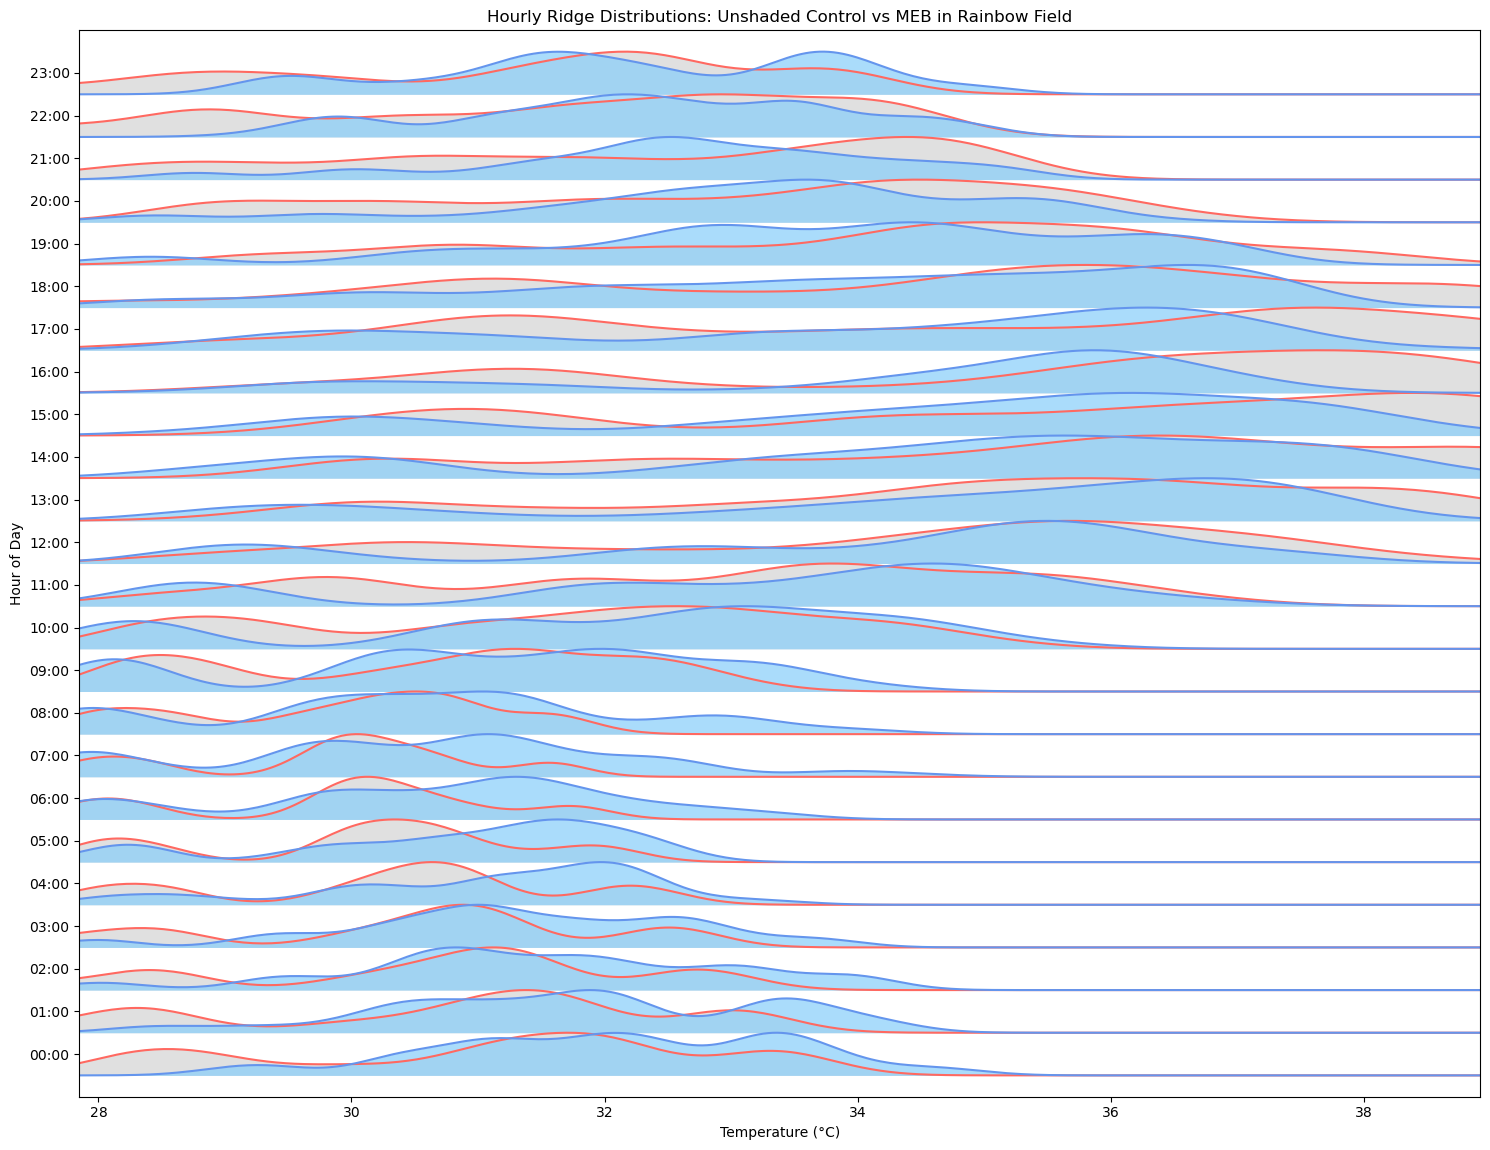

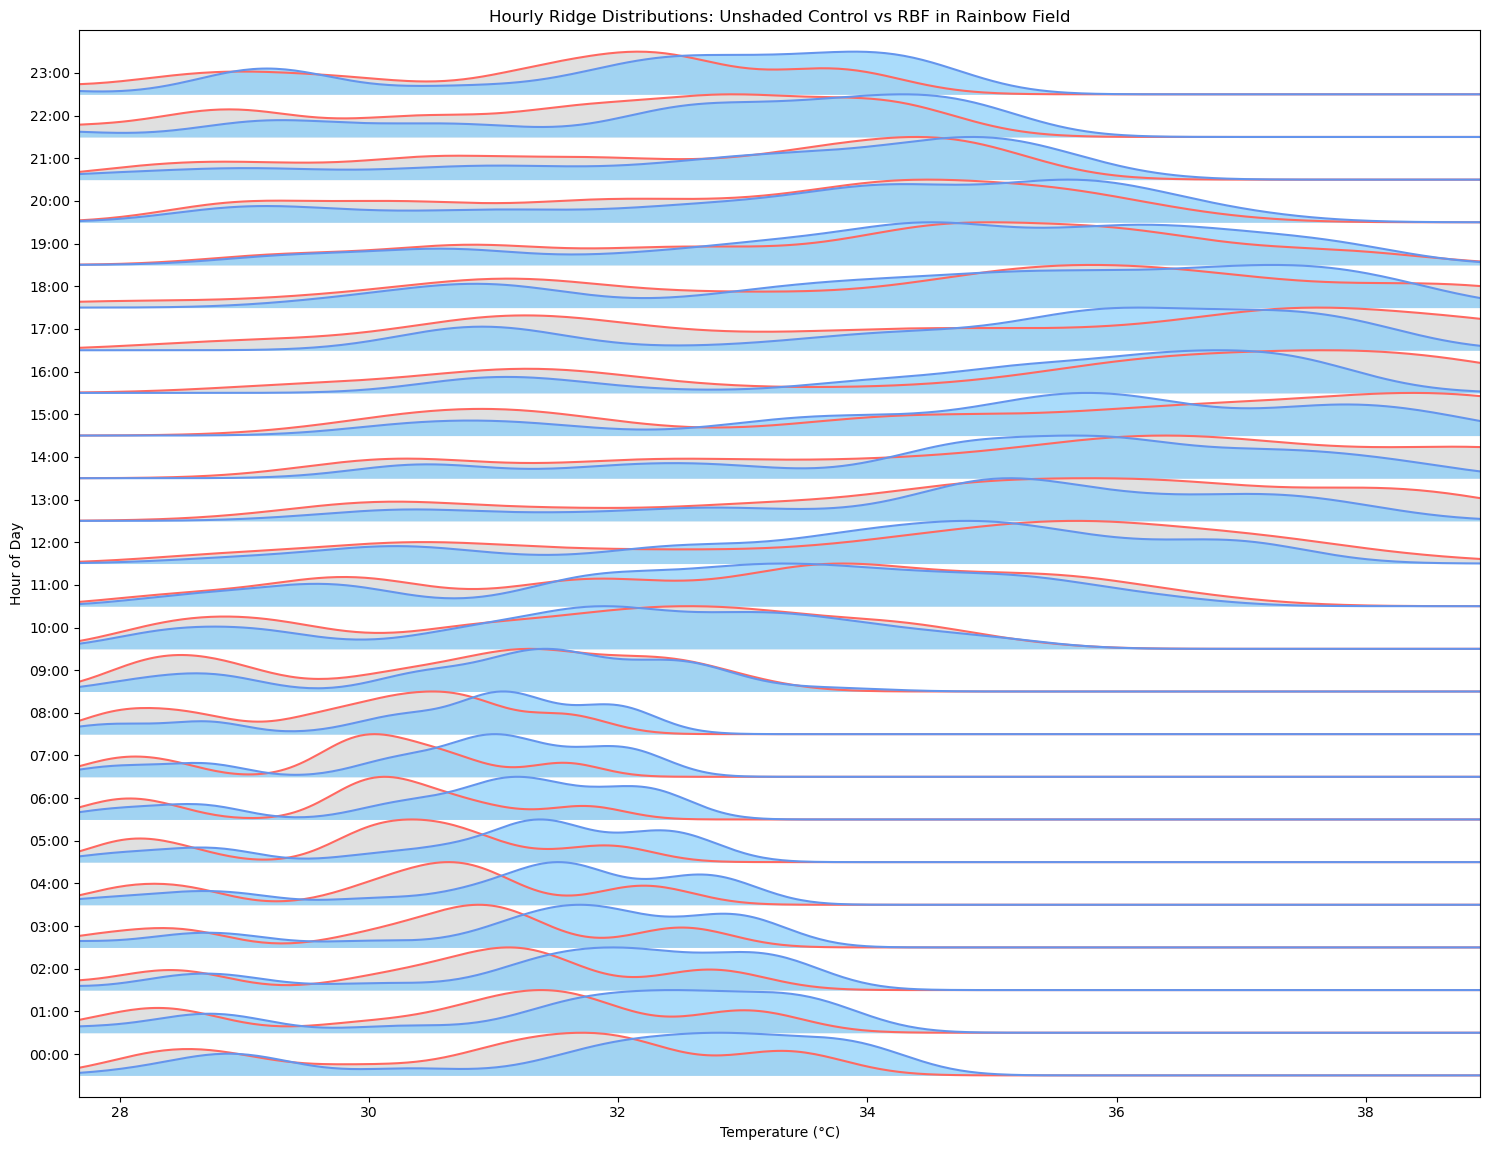

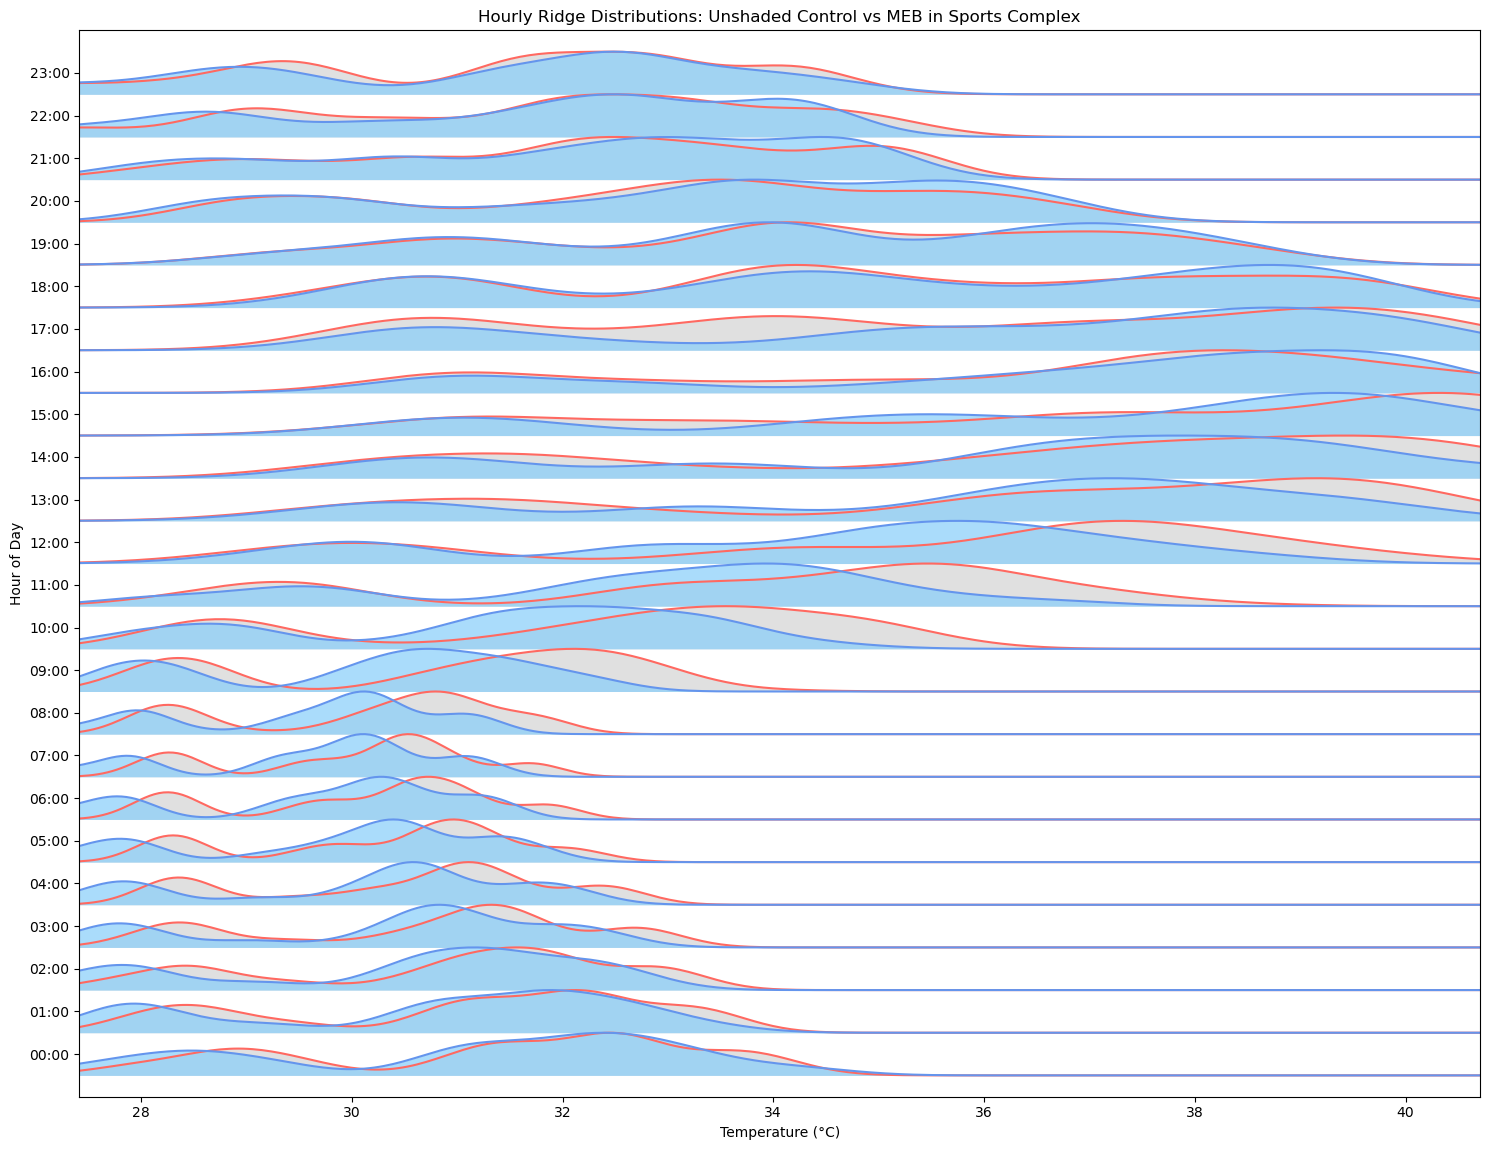

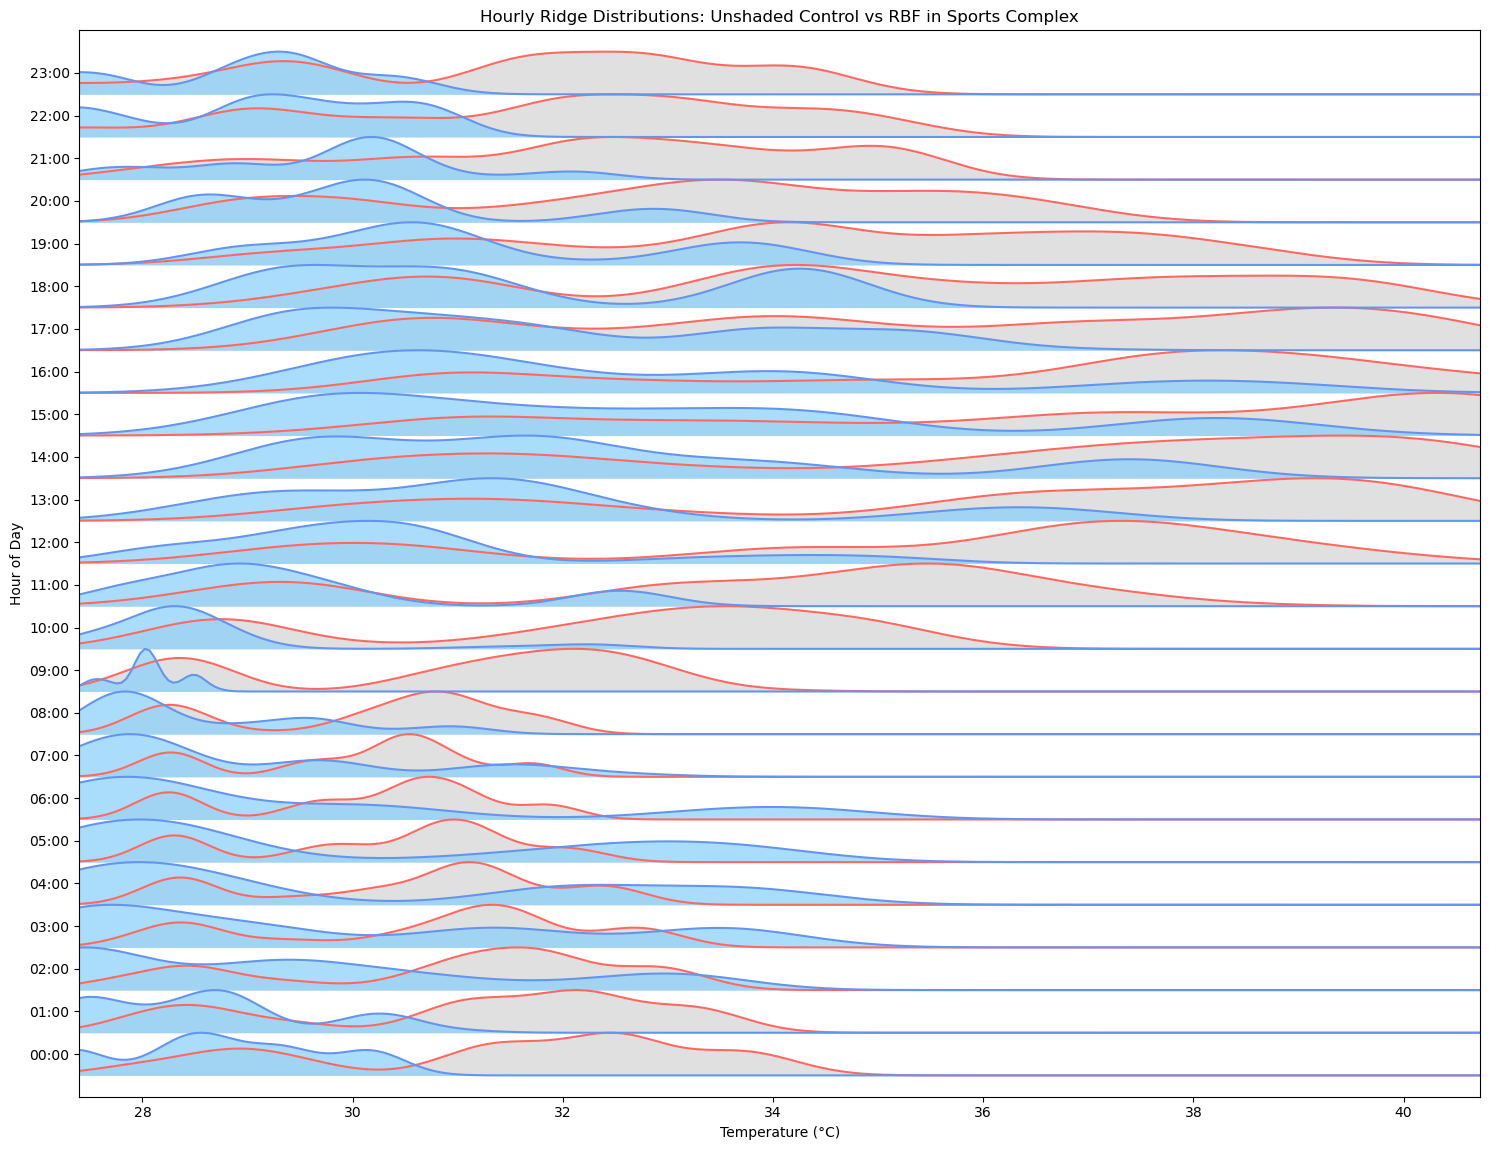

In [7]:
# Ridge (joy) plots per hour: Control vs Intervention (unshaded, post-intervention)
# Two ridges per hour with shared x-scale

import matplotlib.transforms as mtransforms

try:
    from scipy.stats import gaussian_kde
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def _compute_density(values, x_grid):
    values = np.asarray(values)
    values = values[np.isfinite(values)]
    if values.size < 5:
        return np.zeros_like(x_grid)
    if _HAS_SCIPY:
        kde = gaussian_kde(values)
        dens = kde(x_grid)
    else:
        hist, edges = np.histogram(values, bins=max(20, int(np.sqrt(values.size))), density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        dens = np.interp(x_grid, centers, hist, left=0.0, right=0.0)
        # light smoothing
        kernel = np.array([0.05, 0.24, 0.42, 0.24, 0.05])
        dens = np.convolve(dens, kernel, mode='same')
    # normalize height for consistent ridges
    maxd = dens.max() if np.isfinite(dens).any() else 0
    if maxd > 0:
        dens = dens / maxd
    return dens


def create_hourly_ridge_plot(settlement, intervention_type='MEB', period='Full', shaded=False):
    # Pick unshaded control and intervention loggers
    ctrl = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == 'CONTROL') &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()
    itv = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) &
        (logger_flags_df['Intervention'] == intervention_type) &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()
    if not ctrl or not itv:
        print(f"No unshaded loggers for {settlement} - {intervention_type}")
        return

    # Post-intervention window
    rows = logger_flags_df[(logger_flags_df['Settlement'] == settlement) & (logger_flags_df['Intervention'] == intervention_type)]
    if rows.empty:
        print(f"Missing intervention window for {settlement} - {intervention_type}")
        return
    start = pd.to_datetime(rows['Intervention_Start'].iloc[0])
    end = pd.to_datetime(rows['Post_Intervention_End'].iloc[0])

    df = master_df.copy()
    df['Hour'] = df['DateTime'].dt.hour
    # plausibility filter
    for c in [c for c in df.columns if c not in ['DateTime', 'Env_Temperature', 'Hour']]:
        df[c] = df[c].where((df[c] >= TEMP_MIN_PLAUSIBLE) & (df[c] <= TEMP_MAX))

    if period == 'Day':
        df = df[(df['Hour'] >= 6) & (df['Hour'] < 19)]
        hours_range = list(range(6, 19))
    elif period == 'Night':
        df = df[(df['Hour'] < 6) | (df['Hour'] >= 19)]
        hours_range = list(range(19, 24)) + list(range(0, 6))
    else:
        hours_range = list(range(24))

    post = df[(df['DateTime'] >= start) & (df['DateTime'] <= end)].copy()
    if post.empty:
        print(f"No post-intervention data for {settlement} - {intervention_type}")
        return

    ctrl_active = [lg for lg in ctrl if lg in post.columns and post[lg].notna().any()]
    itv_active = [lg for lg in itv if lg in post.columns and post[lg].notna().any()]
    if not ctrl_active or not itv_active:
        print(f"Insufficient active loggers for {settlement} - {intervention_type}")
        return

    # Build per-hour pooled means (across loggers) for both groups
    hour_vals = {}
    for hr in hours_range:
        hr_mask = post['Hour'] == hr
        if not hr_mask.any():
            continue
        block = post.loc[hr_mask]
        ctrl_rows = block[ctrl_active].mean(axis=1, skipna=True).dropna()
        itv_rows = block[itv_active].mean(axis=1, skipna=True).dropna()
        if ctrl_rows.empty or itv_rows.empty:
            continue
        hour_vals[hr] = (ctrl_rows.values, itv_rows.values)

    if not hour_vals:
        print(f"No hourly distributions for {settlement} - {intervention_type}")
        return

    # Shared x scale
    all_vals = np.concatenate([arr for pair in hour_vals.values() for arr in pair])
    x_min = np.nanpercentile(all_vals, 1)
    x_max = np.nanpercentile(all_vals, 99)
    x_grid = np.linspace(x_min, x_max, 300)

    # Layout
    ridge_height = 0.4
    fig_height = max(6, ridge_height * len(hour_vals) + 2)
    fig, ax = plt.subplots(figsize=(15, fig_height))

    # Plot from bottom (earliest hour) to top
    sorted_hours = sorted(hour_vals.keys(), key=lambda h: (h+24) % 24)
    y_ticks = []
    y_ticklabels = []

    for i, hr in enumerate(sorted_hours):
        y0 = i * ridge_height
        ctrl_v, itv_v = hour_vals[hr]
        d_ctrl = _compute_density(ctrl_v, x_grid)
        d_itv = _compute_density(itv_v, x_grid)

        # Control ridge
        ax.fill_between(x_grid, y0, y0 + d_ctrl * ridge_height,
                        color=DEFAULT_COLORS['control_box'], alpha=0.7, linewidth=0)
        ax.plot(x_grid, y0 + d_ctrl * ridge_height,
                color=DEFAULT_COLORS['control_mean'], linewidth=1.5)
        # Intervention ridge
        ax.fill_between(x_grid, y0, y0 + d_itv * ridge_height,
                        color=DEFAULT_COLORS['intervention_box'], alpha=0.7, linewidth=0)
        ax.plot(x_grid, y0 + d_itv * ridge_height,
                color=DEFAULT_COLORS['intervention_mean'], linewidth=1.5)

        y_ticks.append(y0 + ridge_height * 0.5)
        y_ticklabels.append(f"{hr:02d}:00")

    ax.set_ylim(-ridge_height * 0.5, ridge_height * (len(sorted_hours) + 0.5))
    ax.set_xlim(x_min, x_max)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticklabels)
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Hour of Day')
    ax.set_title(f'Hourly Ridge Distributions: Unshaded Control vs {intervention_type} in {settlement}')

    plt.tight_layout()
    plt.show()

# Generate four ridge plots
for st, itv in [('Rainbow Field', 'MEB'), ('Rainbow Field', 'RBF'), ('Sports Complex', 'MEB'), ('Sports Complex', 'RBF')]:
    create_hourly_ridge_plot(st, itv, period='Full', shaded=False)



Analyzing Rainbow Field - MEB - Unshaded - Full
Active control loggers: ['R-09', 'R-11', 'R-12', 'R-14']
Active intervention loggers: ['U-04', 'U-08', 'U-12']
Processing 4 loggers: ['R-09', 'R-11', 'R-12', 'R-14']
Processing 3 loggers: ['U-04', 'U-08', 'U-12']

Control Statistics Summary:
            Hour        max        min       mean
count  24.000000  24.000000  24.000000  24.000000
mean   11.500000   1.597002  -1.071321   0.131789
std     7.071068   1.685973   0.958723   1.229221
min     0.000000  -1.568760  -2.951469  -2.304859
25%     5.750000   0.725609  -1.857167  -0.364919
50%    11.500000   1.309437  -0.868162   0.079170
75%    17.250000   3.281502  -0.509889   1.053370
max    23.000000   4.311098   0.447794   2.043652

Intervention Statistics Summary:
            Hour        max        min       mean
count  24.000000  24.000000  24.000000  24.000000
mean   11.500000   2.103843  -2.170381   0.001796
std     7.071068   1.209768   1.129767   0.949368
min     0.000000  -0.7630

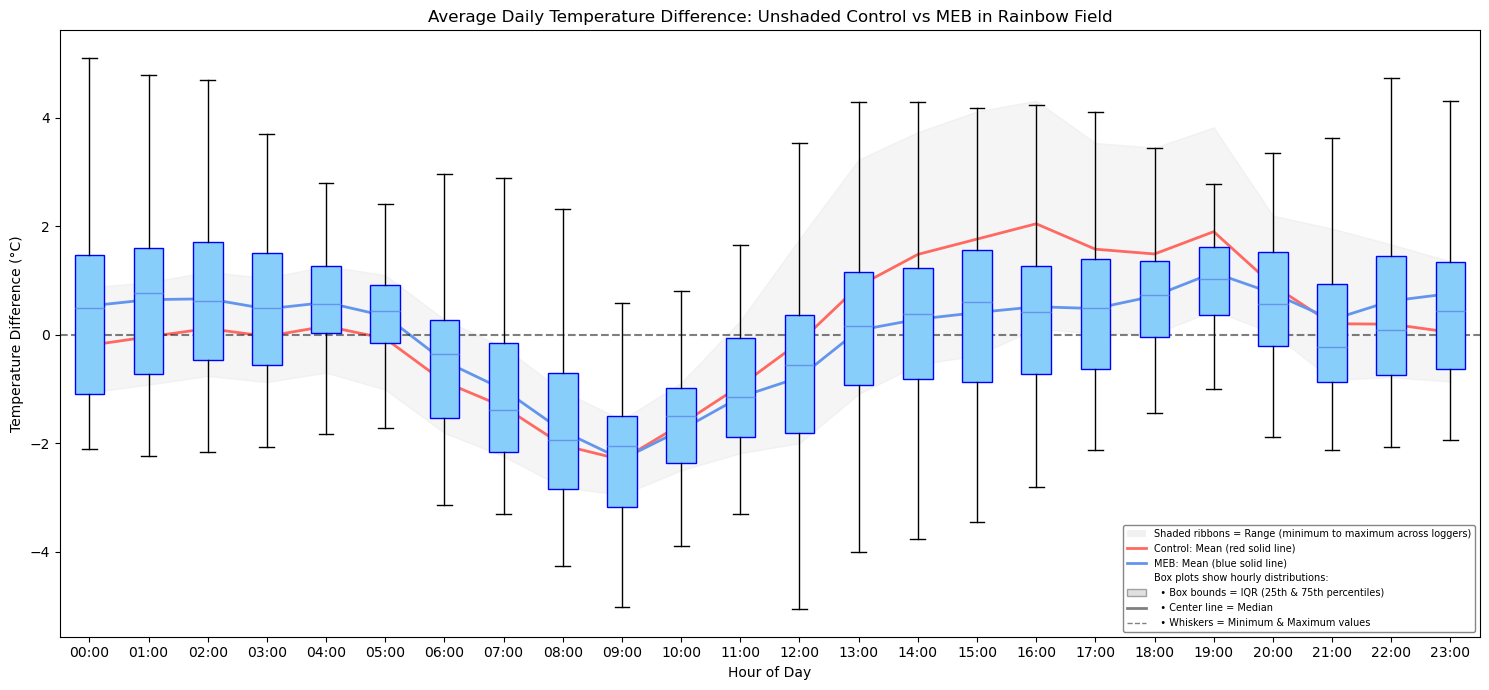

\n================================================================================
MANUSCRIPT FIGURE LEGEND (Copy-paste ready):
\nFigure X. Hourly temperature difference comparison between unshaded control
(n=4 independent logger locations) and MEB
intervention structures (n=3 independent logger locations)
in Rainbow Field during post-intervention period.\n
Data presentation: Box plots show the interquartile range (IQR; 25th to 75th
percentile), with the horizontal line within each box indicating the median.
Whiskers extend to minimum and maximum values (no outliers excluded). Shaded
ribbons show the range (minimum to maximum) across loggers. Solid lines indicate
mean hourly temperature differences. Each logger represents one biological
replicate (independent dwelling structure), with ~54,000 temperature measurements
(technical replicates) collected at 1-minute intervals during the post-intervention
period. Data aggregation: (1) for each logger, hourly mean temperature difference
(indo

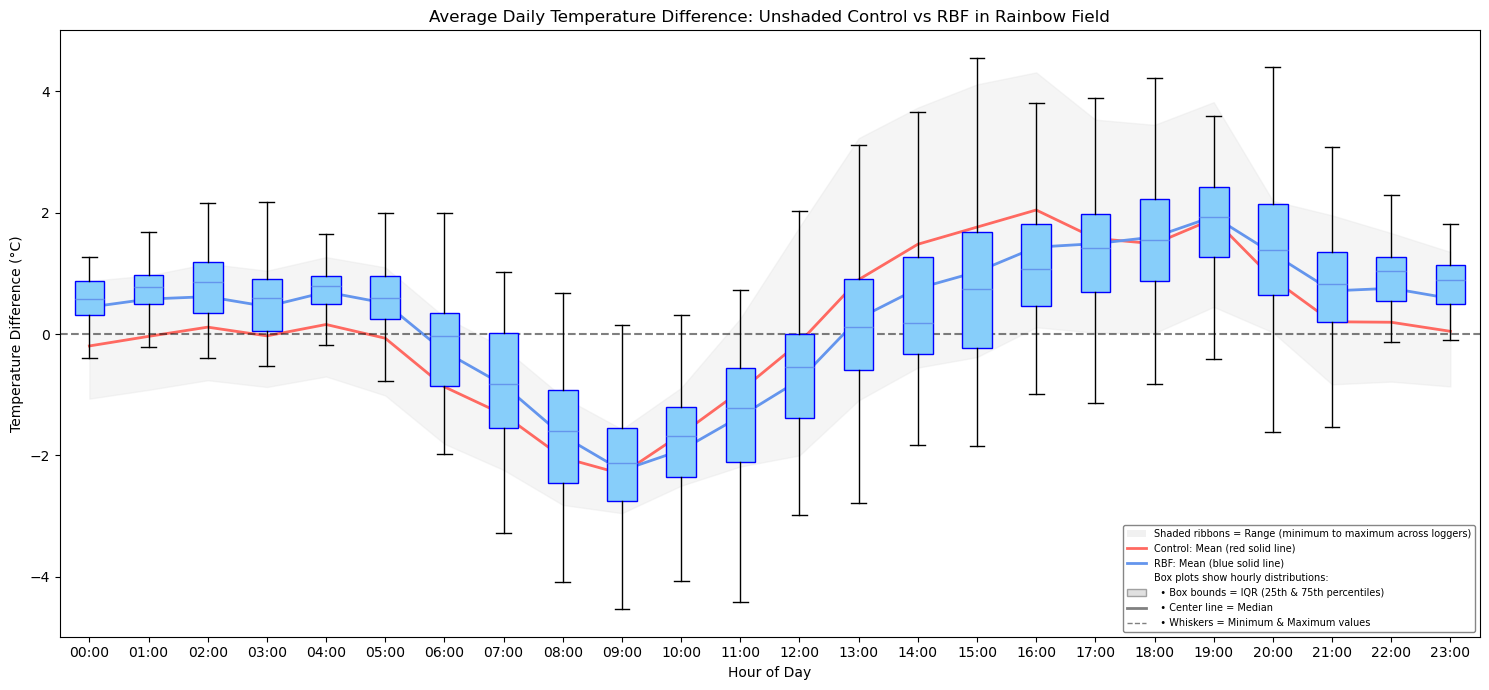

\n================================================================================
MANUSCRIPT FIGURE LEGEND (Copy-paste ready):
\nFigure X. Hourly temperature difference comparison between unshaded control
(n=4 independent logger locations) and RBF
intervention structures (n=4 independent logger locations)
in Rainbow Field during post-intervention period.\n
Data presentation: Box plots show the interquartile range (IQR; 25th to 75th
percentile), with the horizontal line within each box indicating the median.
Whiskers extend to minimum and maximum values (no outliers excluded). Shaded
ribbons show the range (minimum to maximum) across loggers. Solid lines indicate
mean hourly temperature differences. Each logger represents one biological
replicate (independent dwelling structure), with ~54,000 temperature measurements
(technical replicates) collected at 1-minute intervals during the post-intervention
period. Data aggregation: (1) for each logger, hourly mean temperature difference
(indo

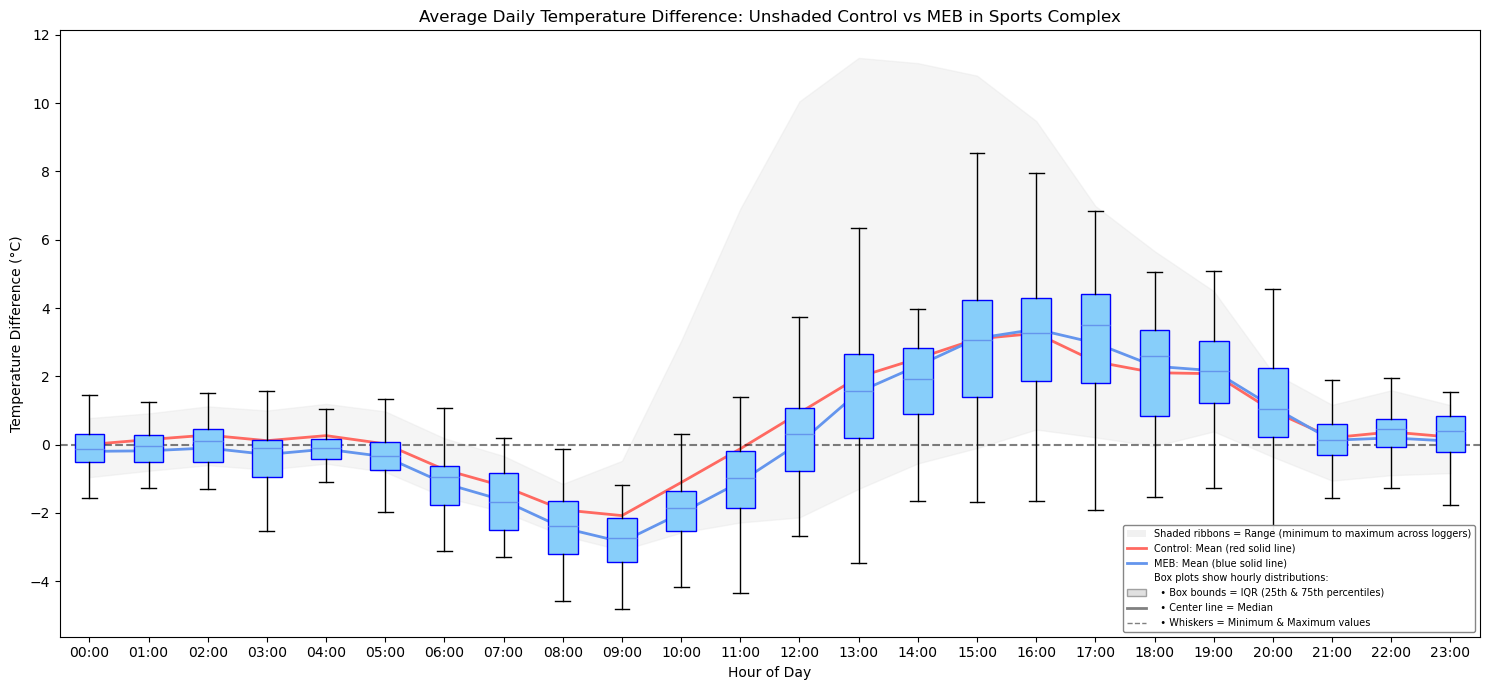

\n================================================================================
MANUSCRIPT FIGURE LEGEND (Copy-paste ready):
\nFigure X. Hourly temperature difference comparison between unshaded control
(n=7 independent logger locations) and MEB
intervention structures (n=3 independent logger locations)
in Sports Complex during post-intervention period.\n
Data presentation: Box plots show the interquartile range (IQR; 25th to 75th
percentile), with the horizontal line within each box indicating the median.
Whiskers extend to minimum and maximum values (no outliers excluded). Shaded
ribbons show the range (minimum to maximum) across loggers. Solid lines indicate
mean hourly temperature differences. Each logger represents one biological
replicate (independent dwelling structure), with ~54,000 temperature measurements
(technical replicates) collected at 1-minute intervals during the post-intervention
period. Data aggregation: (1) for each logger, hourly mean temperature difference
(ind

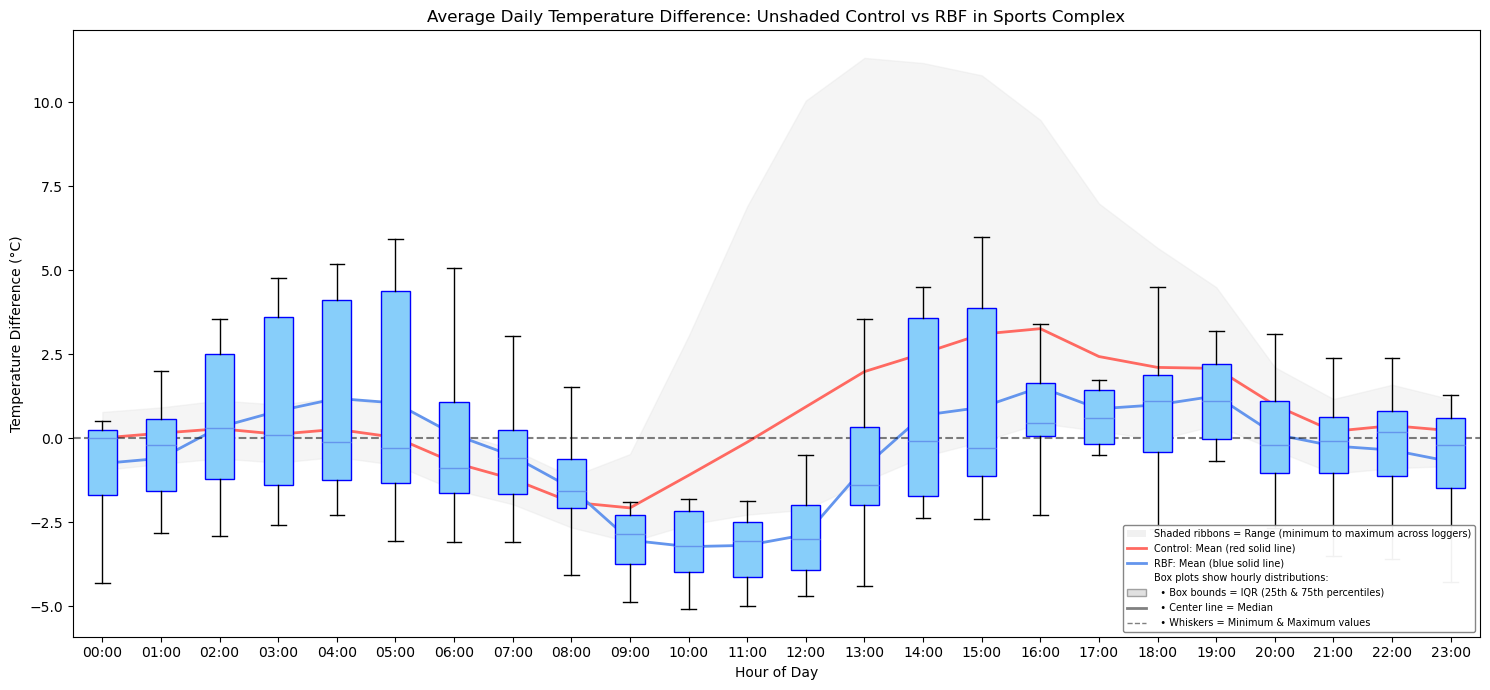

\n================================================================================
MANUSCRIPT FIGURE LEGEND (Copy-paste ready):
\nFigure X. Hourly temperature difference comparison between unshaded control
(n=7 independent logger locations) and RBF
intervention structures (n=1 independent logger locations)
in Sports Complex during post-intervention period.\n
Data presentation: Box plots show the interquartile range (IQR; 25th to 75th
percentile), with the horizontal line within each box indicating the median.
Whiskers extend to minimum and maximum values (no outliers excluded). Shaded
ribbons show the range (minimum to maximum) across loggers. Solid lines indicate
mean hourly temperature differences. Each logger represents one biological
replicate (independent dwelling structure), with ~54,000 temperature measurements
(technical replicates) collected at 1-minute intervals during the post-intervention
period. Data aggregation: (1) for each logger, hourly mean temperature difference
(ind

In [8]:
import pandas as pd
import numpy.ma as ma
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

def create_average_day_comparison_plot(
    settlement, 
    intervention_type='MEB',
    period='Full',
    shaded=True,
    colors=None
):
    """
    Create comparison plot of temperature differences for an average 24-hour day
    
    Parameters:
    -----------
    settlement : str
        Name of the settlement
    intervention_type : str
        Type of intervention (default: 'MEB')
    period : str
        Time period to plot ('Full', 'Day', or 'Night')
    shaded : bool
        Whether to analyze shaded (True) or unshaded (False) structures
    colors : dict, optional
        Dictionary to customize plot colors
    """
    default_colors = {
        'control_range': '#E0E0E0',
        'intervention_range': '#ADD8E6',
        'control_mean': '#FF6961',
        'intervention_mean': '#6495ED',
        'control_box': '#D3D3D3',
        'intervention_box': '#87CEFA'
    }
    
    if colors is not None:
        default_colors.update(colors)
    
    # Load data
    temp_diff_df = pd.read_csv('temperature_differences.csv', parse_dates=['DateTime'])
    logger_flags_df = pd.read_csv('logger_flags.csv')
    temp_diff_df['DateTime'] = pd.to_datetime(temp_diff_df['DateTime'])

    control_loggers = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) & 
        (logger_flags_df['Intervention'] == 'CONTROL') &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()
    
    intervention_loggers = logger_flags_df[
        (logger_flags_df['Settlement'] == settlement) & 
        (logger_flags_df['Intervention'] == intervention_type) &
        (logger_flags_df['Shaded'] == shaded)
    ]['Loggers'].tolist()

    intervention_start = pd.to_datetime(
        logger_flags_df[
            (logger_flags_df['Settlement'] == settlement) & 
            (logger_flags_df['Intervention'] == intervention_type)
        ]['Intervention_Start'].iloc[0]
    )
    
    intervention_end = pd.to_datetime(
        logger_flags_df[
            (logger_flags_df['Settlement'] == settlement) & 
            (logger_flags_df['Intervention'] == intervention_type)
        ]['Post_Intervention_End'].iloc[0]
    )

    def filter_active_loggers(loggers, df, start_date, end_date):
        active_loggers = []
        for logger in loggers:
            logger_data = df[
                (df['DateTime'] >= start_date) & 
                (df['DateTime'] <= end_date)
            ][logger]
            if not logger_data.empty and not logger_data.isna().all():
                active_loggers.append(logger)
            else:
                print(f"Warning: Logger {logger} has no valid data during intervention period")
        return active_loggers

    post_intervention_df = temp_diff_df[
        (temp_diff_df['DateTime'] >= intervention_start) & 
        (temp_diff_df['DateTime'] <= intervention_end)
    ].copy()

    active_control_loggers = filter_active_loggers(
        control_loggers, 
        post_intervention_df, 
        intervention_start, 
        intervention_end
    )
    
    active_intervention_loggers = filter_active_loggers(
        intervention_loggers, 
        post_intervention_df, 
        intervention_start, 
        intervention_end
    )

    print(f"\nAnalyzing {settlement} - {intervention_type} - {'Shaded' if shaded else 'Unshaded'} - {period}")
    print(f"Active control loggers: {active_control_loggers}")
    print(f"Active intervention loggers: {active_intervention_loggers}")

    # Check if we have enough active loggers for comparison
    if not active_control_loggers or not active_intervention_loggers:
        print(f"Insufficient active loggers for {settlement} - {intervention_type} - "
              f"{'Shaded' if shaded else 'Unshaded'} - {period}")
        return

    post_intervention_df['Hour'] = post_intervention_df['DateTime'].dt.hour

    # Define hours range based on period
    if period == 'Day':
        post_intervention_df = post_intervention_df[
            (post_intervention_df['Hour'] >= 6) & 
            (post_intervention_df['Hour'] < 19)
        ]
        hours_range = range(6, 19)
    elif period == 'Night':
        post_intervention_df = post_intervention_df[
            (post_intervention_df['Hour'] < 6) | 
            (post_intervention_df['Hour'] >= 19)
        ]
        evening_hours = list(range(19, 24))
        morning_hours = list(range(0, 6))
        hours_range = evening_hours + morning_hours
    else:  # Full day
        hours_range = range(24)

    def calculate_hourly_stats(loggers, df):
        hourly_stats = []
        
        if not loggers:
            print("No loggers provided for analysis")
            return pd.DataFrame()

        print(f"Processing {len(loggers)} loggers: {loggers}")
        
        for hour in hours_range:
            hour_data = df[df['Hour'] == hour][loggers]
            hour_data = hour_data.replace(0, np.nan)
            hour_data = hour_data.dropna(how='all')
            
            if not hour_data.empty:
                try:
                    if len(loggers) == 1:
                        # For single logger, calculate mean and create artificial range
                        mean_val = hour_data.mean(axis=1).mean()
                        std_val = hour_data.mean(axis=1).std()
                        
                        # Create range as mean ± standard deviation
                        # If std is too small or nan, use a minimum range
                        if pd.isna(std_val) or std_val < 0.1:
                            range_margin = abs(mean_val) * 0.1 if mean_val != 0 else 0.1
                        else:
                            range_margin = std_val
                        
                        max_val = mean_val + range_margin
                        min_val = mean_val - range_margin
                    else:
                        max_val = hour_data.max(axis=1).mean()
                        min_val = hour_data.min(axis=1).mean()
                        mean_val = hour_data.mean(axis=1).mean()
                        std_val = hour_data.mean(axis=1).std()

                    if pd.isna([max_val, min_val, mean_val]).any():
                        print(f"Warning: NaN values found for hour {hour}")
                        continue
                        
                    stats = {
                        'Hour': hour,
                        'max': max_val,
                        'min': min_val,
                        'mean': mean_val,
                        'std': std_val if not pd.isna(std_val) else 0,
                        'values': hour_data.mean(axis=1).values
                    }
                    hourly_stats.append(stats)
                except Exception as e:
                    print(f"Error processing hour {hour}: {str(e)}")
                    continue
        
        if not hourly_stats:
            print("No valid statistics could be calculated")
            return pd.DataFrame()
            
        return pd.DataFrame(hourly_stats)

    control_stats = calculate_hourly_stats(active_control_loggers, post_intervention_df)
    intervention_stats = calculate_hourly_stats(active_intervention_loggers, post_intervention_df)

    if control_stats.empty or intervention_stats.empty:
        print("No valid statistics available for plotting")
        return

    print("\nControl Statistics Summary:")
    print(control_stats[['Hour', 'max', 'min', 'mean']].describe())
    print("\nIntervention Statistics Summary:")
    print(intervention_stats[['Hour', 'max', 'min', 'mean']].describe())

    fig, ax = plt.subplots(figsize=(15, 7))  # Reduced height from 10 to 6

    x_values = control_stats['plot_hour'] if period == 'Night' else control_stats['Hour']

    try:
        if not control_stats.empty and not np.isnan(control_stats['max']).all():
            control_range = ax.fill_between(control_stats['Hour'],
                                          control_stats['max'],
                                          control_stats['min'],
                                          alpha=0.3,
                                          color=default_colors['control_range'],
                                          label='Control Range')
        else:
            print("Warning: Invalid control range data")

        x_values = intervention_stats['plot_hour'] if period == 'Night' else intervention_stats['Hour']

        # Comment out intervention range (blue shaded area) to reduce plot messiness
        # if not intervention_stats.empty and not np.isnan(intervention_stats['max']).all():
        #     intervention_range = ax.fill_between(intervention_stats['Hour'],
        #                                        intervention_stats['max'],
        #                                        intervention_stats['min'],
        #                                        alpha=0.5,
        #                                        color=default_colors['intervention_range'],
        #                                        label='Intervention Range')
        # else:
        #     print("Warning: Invalid intervention range data")

    except Exception as e:
        print(f"Error during plotting: {str(e)}")
        return

    # Plot mean lines
    x_values = control_stats['plot_hour'] if period == 'Night' else control_stats['Hour']
    control_mean, = ax.plot(x_values,
                          control_stats['mean'],
                          color=default_colors['control_mean'],
                          label='Control Mean',
                          linewidth=2)
    
    x_values = intervention_stats['plot_hour'] if period == 'Night' else intervention_stats['Hour']
    intervention_mean, = ax.plot(x_values,
                               intervention_stats['mean'],
                               color=default_colors['intervention_mean'],
                               label='Intervention Mean',
                               linewidth=2)

    ax.axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    # Create box plots
    control_boxes = []
    intervention_boxes = []
    
    # Comment out control boxplots (grey ones) to reduce plot messiness
    # for _, row in control_stats.iterrows():
    #     x_pos = row['plot_hour'] if period == 'Night' else row['Hour']
    #     control_box = ax.boxplot(row['values'],
    #                            positions=[x_pos],
    #                            widths=0.5,
    #                            patch_artist=True,
    #                            boxprops=dict(facecolor=default_colors['control_box'], color='gray'),
    #                            medianprops=dict(color=default_colors['control_mean']),
    #                            showfliers=False)
    #     control_boxes.append(control_box)
    
    for _, row in intervention_stats.iterrows():
        x_pos = row['plot_hour'] if period == 'Night' else row['Hour']
        intervention_box = ax.boxplot(row['values'],
                                    positions=[x_pos],
                                    widths=0.5,
                                    patch_artist=True,
                                    boxprops=dict(facecolor=default_colors['intervention_box'], color='blue'),
                                    medianprops=dict(color=default_colors['intervention_mean']),
                                    showfliers=False)
        intervention_boxes.append(intervention_box)

    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Temperature Difference (°C)')
    shading_str = "Shaded" if shaded else "Unshaded"
    period_str = f" ({period}time)" if period != 'Full' else ""
    ax.set_title(f'Average Daily Temperature Difference{period_str}: {shading_str} Control vs {intervention_type} in {settlement}')

    if period == 'Night':
        plot_hours = list(range(19, 24)) + list(range(24, 30))  # 19-23 and 24-29 (0-5)
        ax.set_xticks(plot_hours)
        hour_labels = [f'{h:02d}:00' if h < 24 else f'{h-24:02d}:00' for h in plot_hours]
        ax.set_xticklabels(hour_labels)
        ax.set_xlim(18.5, 29.5)
    elif period == 'Day':
        ax.set_xticks(list(hours_range))
        ax.set_xticklabels([f'{hour:02d}:00' for hour in hours_range])
        ax.set_xlim(5.5, 19.5)
    else:  # Full day
        ax.set_xticks(list(hours_range))
        ax.set_xticklabels([f'{hour:02d}:00' for hour in hours_range])
        ax.set_xlim(-0.5, 23.5)

    # Create custom legend with visual elements (as required by journal editor)
    from matplotlib.patches import Rectangle, Patch
    from matplotlib.lines import Line2D
    
    legend_elements = [
        # Error bands/ribbons definition
        Patch(facecolor='lightgray', alpha=0.3, label='Shaded ribbons = Range (minimum to maximum across loggers)'),
        
        # Mean lines
        Line2D([0], [0], color=default_colors['control_mean'], linewidth=2, label='Control: Mean (red solid line)'),
        Line2D([0], [0], color=default_colors['intervention_mean'], linewidth=2, label=f'{intervention_type}: Mean (blue solid line)'),
        
        # Box plots definition
        Line2D([0], [0], marker='o', color='w', label='Box plots show hourly distributions:',
               markerfacecolor='none', markersize=0, linewidth=0),
        Patch(facecolor=default_colors['control_box'], edgecolor='gray', alpha=0.7, label='  • Box bounds = IQR (25th & 75th percentiles)'),
        Line2D([0], [0], color='gray', linewidth=2, label='  • Center line = Median'),
        Line2D([0], [0], color='gray', linewidth=1, linestyle='--', label='  • Whiskers = Minimum & Maximum values'),
    ]
    
    ax.legend(handles=legend_elements, 
              loc='lower right',
              fontsize=7,
              framealpha=0.95,
              edgecolor='gray')

    plt.tight_layout()
    plt.show()
    
    # Print manuscript-ready text for figure legend
    print("\\n" + "="*80)
    print("MANUSCRIPT FIGURE LEGEND (Copy-paste ready):")
    print("="*80)
    print(f"\\nFigure X. Hourly temperature difference comparison between {shading_str.lower()} control")
    print(f"(n={len(active_control_loggers)} independent logger locations) and {intervention_type}")
    print(f"intervention structures (n={len(active_intervention_loggers)} independent logger locations)")
    print(f"in {settlement} during post-intervention period.\\n")
    print("Data presentation: Box plots show the interquartile range (IQR; 25th to 75th")
    print("percentile), with the horizontal line within each box indicating the median.")
    print("Whiskers extend to minimum and maximum values (no outliers excluded). Shaded")
    print("ribbons show the range (minimum to maximum) across loggers. Solid lines indicate")
    print("mean hourly temperature differences. Each logger represents one biological")
    print(f"replicate (independent dwelling structure), with ~54,000 temperature measurements")
    print("(technical replicates) collected at 1-minute intervals during the post-intervention")
    print("period. Data aggregation: (1) for each logger, hourly mean temperature difference")
    print("(indoor minus outdoor) was calculated across all measurement days; (2) group")
    print("statistics (mean, median, IQR, range) were then calculated across the n loggers.")
    print("All statistics derived from logger-level means to properly distinguish biological")
    print("from technical replication.")
    print("="*80 + "\\n")

# Settings
settlements = ['Rainbow Field', 'Sports Complex']
intervention_types = ['MEB', 'RBF']
periods = ['Full']
shading_conditions = [False]

custom_colors = {
    'control_range': '#E0E0E0',
    'intervention_range': '#ADD8E6',
    'control_mean': '#FF6961',
    'intervention_mean': '#6495ED',
    'control_box': '#D3D3D3',
    'intervention_box': '#87CEFA'
}

for settlement in settlements:
    for intervention_type in intervention_types:
        for period in periods:
            for shaded in shading_conditions:
                try:
                    create_average_day_comparison_plot(
                        settlement, 
                        intervention_type,
                        period,
                        shaded,
                        colors=custom_colors
                    )
                except Exception as e:
                    print(f"Error creating plot for {settlement} - {intervention_type} - "
                          f"{'Shaded' if shaded else 'Unshaded'} - {period}: {str(e)}")